# Jupyter Notebook: detekcja kasków za pomocą modeli YOLO

Dataset: hard hat workers.v2-dataset-balanceado-50-50.yolov11  pobrany z https://universe.roboflow.com/deneme-pl0tb/hard-hat-50-wb2rk

Modele: yolo11n, yolo11s, yolo11m

| Model       | Parametry |  FLOPs | mAP<sub>50-95</sub> (COCO) | Charakterystyka                                                                                                                                    |
| ----------- | --------: | -----: | -------------------------: | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| **YOLO11n** |   2.6 mln |  6.5 B |                       39.5 | Najmniejszy i najszybszy model. Idealny na urządzenia edge, do prototypowania oraz gdy liczy się szybkość inferencji.                              |
| **YOLO11s** |   9.4 mln | 21.5 B |                       47.0 | Dobry kompromis pomiędzy szybkością i dokładnością. Często najlepszy wybór jako model bazowy.                                                      |
| **YOLO11m** |  20.1 mln | 68.0 B |                       51.5 | Wyraźnie większa dokładność kosztem około 3× większej złożoności obliczeniowej niż YOLO11s. Dobry wybór na mocniejsze GPU. ([Ultralytics Docs][1]) |

[1]: https://docs.ultralytics.com/models/yolo11?utm_source=chatgpt.com "Ultralytics YOLO11 | Ultralytics"



In [7]:
from ultralytics import YOLO
import ultralytics
import torch
from pathlib import Path
import matplotlib.pyplot as plt


# Podstawowe sprawdzenie czy wersje (torch) są poprawne (wsparcie CUDA - GPU)


In [2]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA version in PyTorch:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
CUDA version in PyTorch: 13.0
GPU count: 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
ultralytics.checks()

Ultralytics 8.4.93  Python-3.13.7 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Setup complete  (12 CPUs, 63.3 GB RAM, 711.5/879.3 GB disk)


In [4]:
# ścieżka do datasetu (konfiguracja yamlowa) musi być pobrany (z linku w nagłówku) i rozpakowany
path_to_dataset = Path("data/helmets-dataset/data.yaml")
path_to_dataset.exists()

True

In [5]:
# model yolo jest automatycznie pobierany
# YOLO11n
model_yolo_11 = YOLO("yolo11n.pt")
model_yolo_11s = YOLO("yolo11s.pt")
model_yolo_11m = YOLO("yolo11m.pt")

In [11]:
# Podstawowe trenowanie: obrazki mają 640x640, epok 50
model_yolo_11.train(
    data=path_to_dataset,
    epochs=50,
    imgsz=640,
    device=0
)

Ultralytics 8.4.93  Python-3.13.7 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\helmets-dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002382F547E70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [10]:
model_yolo_11s.train(
    data=path_to_dataset,
    epochs=50,
    imgsz=640,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.102 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.93  Python-3.13.7 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\helmets-dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001FC007701A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [6]:
model_yolo_11m.train(
    data=path_to_dataset,
    epochs=50,
    imgsz=640,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.103 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.93  Python-3.13.7 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\helmets-dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001FD00620AD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [1]:
from src.plots import plot_learning_curves  # wyrysowanie krzywych uczenia

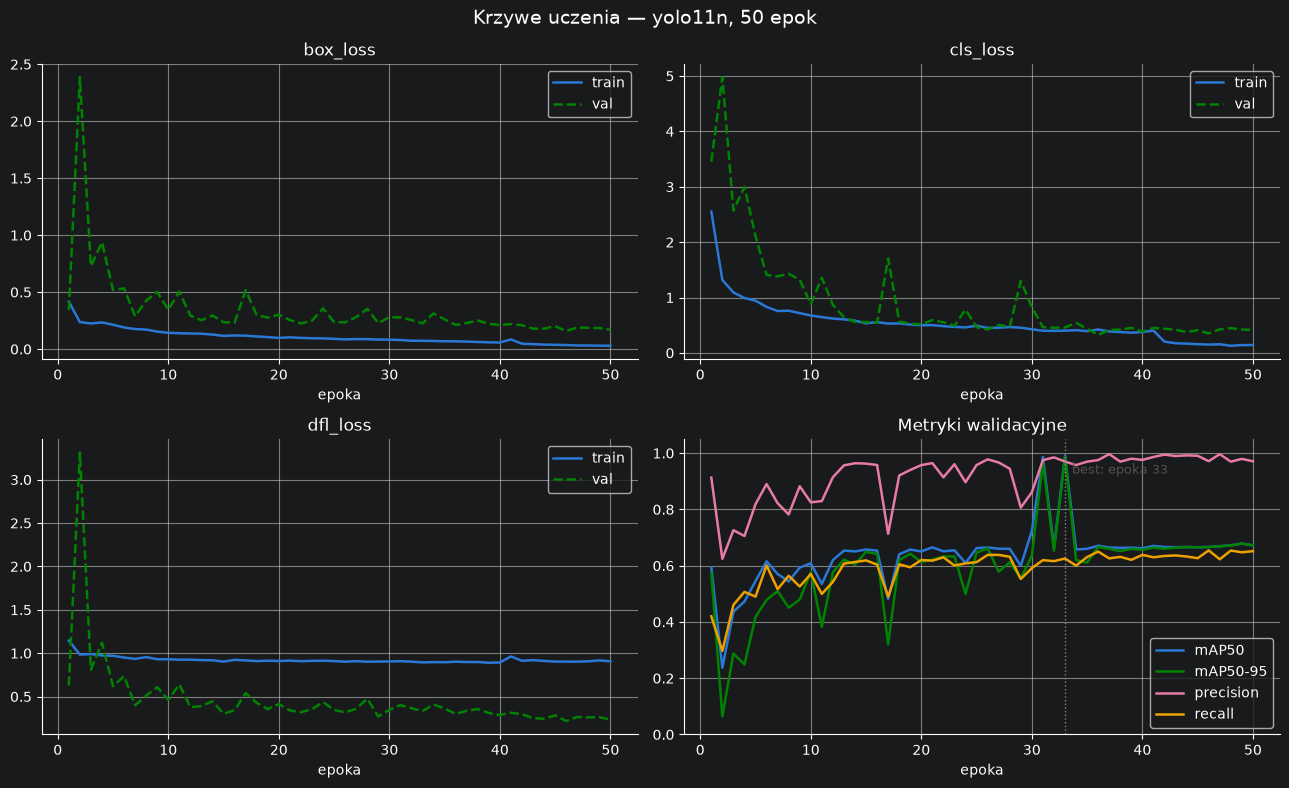

In [2]:
plot_learning_curves("runs/detect/train/results.csv", title="Krzywe uczenia — yolo11n, 50 epok");

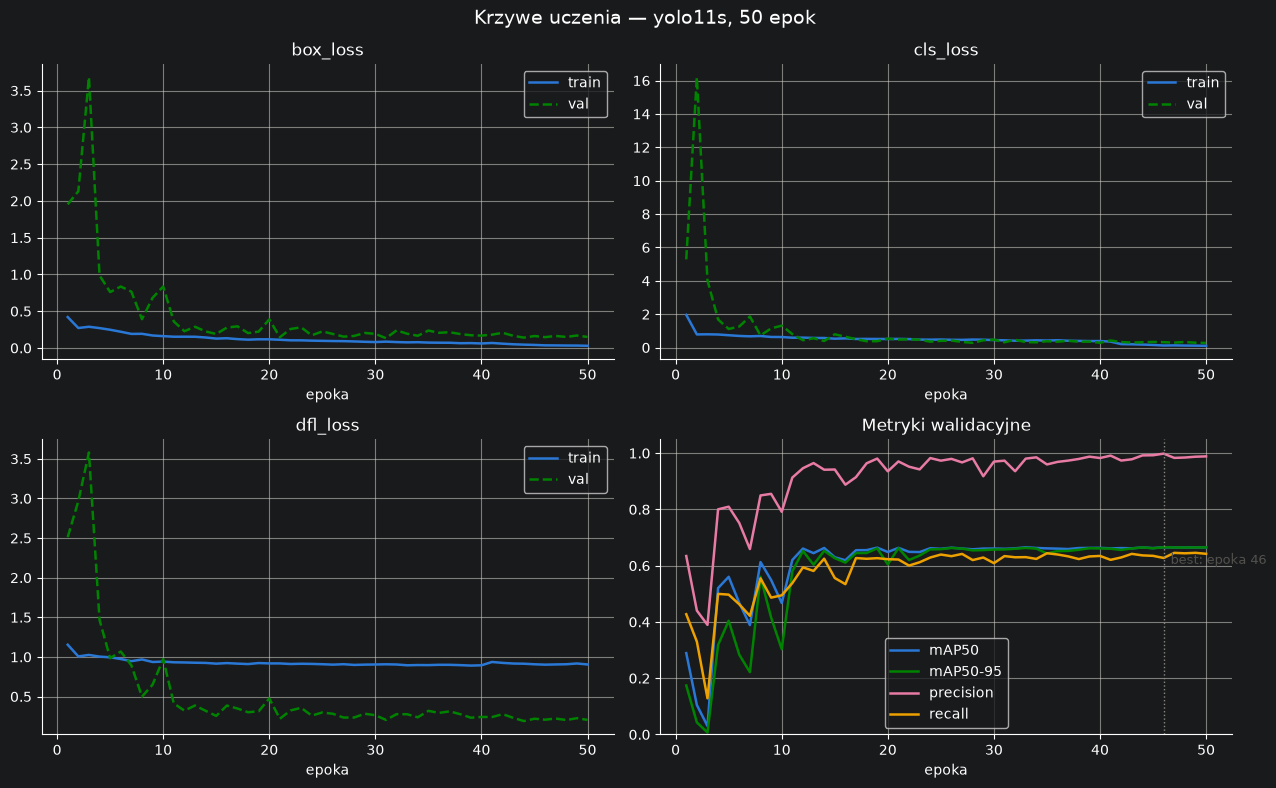

In [3]:
plot_learning_curves("runs/detect/train-2/results.csv", title="Krzywe uczenia — yolo11s, 50 epok");

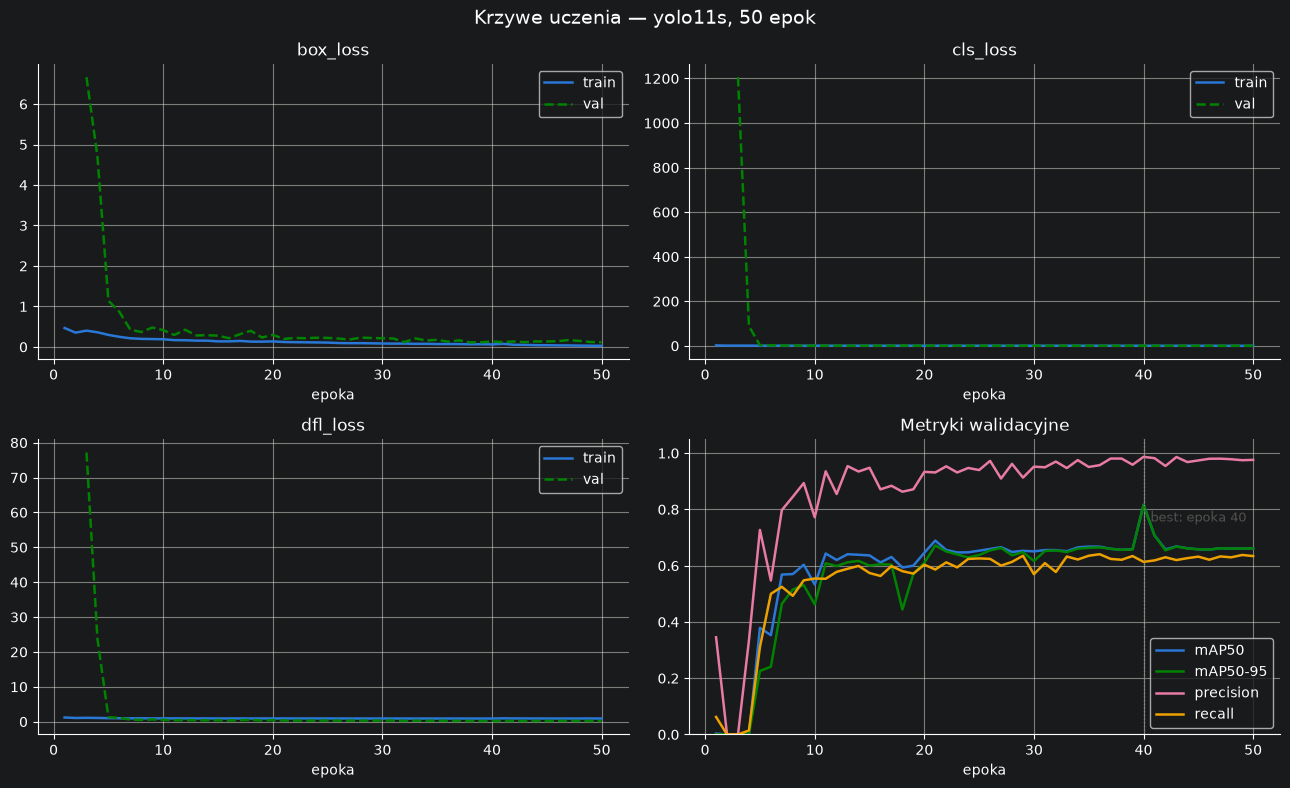

In [2]:
plot_learning_curves("runs/detect/train-4/results.csv", title="Krzywe uczenia — yolo11s, 50 epok");